<a href="https://colab.research.google.com/github/catchtimings/IntroML-labs/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_e_Bay_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задача**: Предобработка и анализ данных о продажах автомобилей на eBay
Цель: Проектируем задачу как анализ данных объявлений о продаже б/у автомобилей с сайта eBay Kleinanzeigen.

**Цель исследования** – очистить полученный датасет и провести разведочный анализ, чтобы выявить закономерности в распределении цен и пробега автомобилей разных марок.

**Данные**: Данные – выгрузка объявлений (2016 г.) от пользователя kaggle или подобного сервиса, содержащая свыше 370 000 записей. Датасет имеет 20 столбцов с информацией об объявлении (дата создания, продавец и т.д.) и о самом автомобиле (цена price, пробег kilometer, год регистрации yearOfRegistration, марка brand, модель model и др.).

Данные взяты из [kaggle](https://www.kaggle.com/code/stieranka/data-cleaning-car-dataset/input)

<h1> Предобработка данных</h1>

1. **Импорт библиотек**




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. **Загрузка данных**:

Прочитайте файл с данными в переменную df

In [ ]:
df = pd.read_csv('autos.csv', encoding='latin1')

3. **Первые строки**:

Выведите первые 5 строк таблицы командой df.head(), чтобы убедиться, что данные считаны корректно.

In [ ]:
df.head(5)

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,andere,"150,000km",3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,7er,"150,000km",6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,golf,"70,000km",7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,"70,000km",6,benzin,smart,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,focus,"150,000km",7,benzin,ford,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50


4. **Общая информация и описательная статистика**:

 получите сводку: количество строк, столбцов, типов данных и ненулевых значений в каждом столбце. Сделайте выводы.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   dateCrawled          50000 non-null  object
 1   name                 50000 non-null  object
 2   seller               50000 non-null  object
 3   offerType            50000 non-null  object
 4   price                50000 non-null  object
 5   abtest               50000 non-null  object
 6   vehicleType          44905 non-null  object
 7   yearOfRegistration   50000 non-null  int64 
 8   gearbox              47320 non-null  object
 9   powerPS              50000 non-null  int64 
 10  model                47242 non-null  object
 11  odometer             50000 non-null  object
 12  monthOfRegistration  50000 non-null  int64 
 13  fuelType             45518 non-null  object
 14  brand                50000 non-null  object
 15  notRepairedDamage    40171 non-null  object
 16  date

###### Микровывод

- Датасет имеет 50_000 строк и 20 столбцов
- Типы данных: int64(5), object(15)

5. **Названия столбцов**:

Посмотрите список названий столбцов (df.columns). Обратите внимание на стиль: многие имена написаны в camelCase (смешение прописных и строчных, например dateCrawled, yearOfRegistration), есть символы подчёркивания или пробелы.

In [ ]:
df.columns

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'odometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')

6 **Переименование столбцов:**

Приведите названия столбцов к единообразному виду – например, к snake_case: все буквы строчные, слова разделены символом _. Это упростит дальнейшую работу с таблицей
. Например, замените yearOfRegistration → year_of_registration, notRepairedDamage → not_repaired_damage и т.д.

In [ ]:
df.columns = df.columns.str.replace('([a-z])([A-Z])', r'\1_\2', regex=True).str.lower()
df.columns

Index(['date_crawled', 'name', 'seller', 'offer_type', 'price', 'abtest',
       'vehicle_type', 'year_of_registration', 'gearbox', 'power_ps', 'model',
       'odometer', 'month_of_registration', 'fuel_type', 'brand',
       'not_repaired_damage', 'date_created', 'nr_of_pictures', 'postal_code',
       'last_seen'],
      dtype='object')

7. **Пропущенные значения:**

Подсчитайте общее количество пропусков по столбцам,

In [ ]:
df.isnull().sum()

,0
date_crawled,0
name,0
seller,0
offer_type,0
price,0
abtest,0
vehicle_type,5095
year_of_registration,0
gearbox,2680
power_ps,0


8. **Дубликаты**:

Проверьте наличие полных дубликатов строк и при необходимости удалите их, чтобы каждая запись была уникальной.

In [ ]:
df.duplicated().sum()

np.int64(0)

9. **Стиль данных**:

Преобразуйте типы данных там, где это необходимо. Например, столбцы с датами (dateCrawled, dateCreated, lastSeen) желательно перевести в тип datetime, чтобы работать с ними как с датами. Убедитесь, что числовые столбцы (price, kilometer, powerPS и др.) имеют числовой тип (int или float).

In [ ]:
df['date_crawled'] = pd.to_datetime(df['date_crawled'])
df['date_created'] = pd.to_datetime(df['date_created'])
df['last_seen'] = pd.to_datetime(df['last_seen'])


df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df['odometer'] = df['odometer'].str.replace('km', '', regex=False)
df['odometer'] = df['odometer'].str.replace(',', '', regex=False)
df['odometer'] = df['odometer'].str.strip()
df['odometer'] = pd.to_numeric(df['odometer'], errors='coerce')


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_crawled           50000 non-null  datetime64[ns]
 1   name                   50000 non-null  object        
 2   seller                 50000 non-null  object        
 3   offer_type             50000 non-null  object        
 4   price                  11360 non-null  float64       
 5   abtest                 50000 non-null  object        
 6   vehicle_type           44905 non-null  object        
 7   year_of_registration   50000 non-null  int64         
 8   gearbox                47320 non-null  object        
 9   power_ps               50000 non-null  int64         
 10  model                  47242 non-null  object        
 11  odometer               50000 non-null  int64         
 12  month_of_registration  50000 non-null  int64         
 13  f

10. **Удаление неинформативных столбцов**:

Определите столбцы, практически не несущие полезной информации. Так,
- столбец seller почти всегда принимает значение «privat» (частное лицо) и лишь несколько раз «gewerblich» (компания),
- столбец offer_type – почти всегда «Angebot»,
- столбец nr_of_pictures равен 0 во всех строках.

Эти столбцы не дают вариативности, поэтому их можно удалить (df.drop(columns=[...], inplace=True))

In [ ]:
df.drop(columns=['seller', 'offer_type', 'nr_of_pictures'], inplace=True)
df.columns

Index(['date_crawled', 'name', 'price', 'abtest', 'vehicle_type',
       'year_of_registration', 'gearbox', 'power_ps', 'model', 'odometer',
       'month_of_registration', 'fuel_type', 'brand', 'not_repaired_damage',
       'date_created', 'postal_code', 'last_seen'],
      dtype='object')

11. **Обработка пропусков:**

Решите, как работать с пропущенными значениями. Поскольку это учебный проект, часто выбирается самый строгий вариант – просто удалить все строки с любыми пропусками (df.dropna(inplace=True)). Это приведёт к более «чистой» выборке, хотя и сократит число строк. В результате будет лишь часть исходных данных.

Можно также рассмотреть альтернативы: заполнение медианой/модой для небольшого числа пропусков



In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
date_crawled,0
name,0
price,0
abtest,0
vehicle_type,0
year_of_registration,0
gearbox,0
power_ps,0
model,0
odometer,0


12. **Выбросы и фильтрация**:

- Проанализируйте диапазоны числовых признаков на наличие явных выбросов. Так, в исходных данных по цене есть значения 0 и крайне большие (минимум 0, максимум ~2.1 млрд).

Логично ограничить их: например, удалить автомобили с ценой меньше 500 (по наблюдениям это минимальное реальное значение), а чрезмерно большие значения оставить по условию (или отфильтровать по статистике, например методом IQR). Аналогично, можно ограничить диапазон мощности двигателя (powerPS) реальным диапазоном (например 50–450 PS) и диапазон года регистрации (например, 1900–2016, так как дата последнего объявления – 2016 г. ). Это позволит убрать заведомо неверные данные.

In [ ]:
df = df[df['price'] >= 500]

df = df[(df['power_ps'] >= 50) & (df['power_ps'] <= 450)]

df = df[(df['year_of_registration'] >= 1900) & (df['year_of_registration'] <= 2016)]

print(df.shape)
print(df.describe())

(3475, 17)
                        date_crawled        price  year_of_registration  \
count                           3475  3475.000000           3475.000000   
mean   2016-03-21 00:27:20.164891904   747.903597           1998.097842   
min              2016-03-05 14:08:27   500.000000           1977.000000   
25%       2016-03-12 15:41:50.500000   600.000000           1996.000000   
50%              2016-03-20 21:42:34   750.000000           1998.000000   
75%              2016-03-28 21:47:32   899.000000           2000.000000   
max              2016-04-07 11:36:34   999.000000           2014.000000   
std                              NaN   162.690659              3.217268   

          power_ps       odometer  month_of_registration  \
count  3475.000000    3475.000000            3475.000000   
mean     91.061871  142322.302158               5.975540   
min      50.000000    5000.000000               0.000000   
25%      60.000000  150000.000000               3.000000   
50%      82.0

13. **Описательная статистика**:

После очистки данных еще раз используйте df.describe() для числовых столбцов (цена, пробег и т.д.) и df.describe(include="all") для всего фреймворка, чтобы посмотреть, как изменились основные показатели (среднее, медиана, квартили, количества уникальных значений).

In [ ]:
print("Числовые признаки:")
print(df.describe())

print("\nВсе признаки:")
print(df.describe(include="all"))

Числовые признаки:
                        date_crawled        price  year_of_registration  \
count                           3475  3475.000000           3475.000000   
mean   2016-03-21 00:27:20.164891904   747.903597           1998.097842   
min              2016-03-05 14:08:27   500.000000           1977.000000   
25%       2016-03-12 15:41:50.500000   600.000000           1996.000000   
50%              2016-03-20 21:42:34   750.000000           1998.000000   
75%              2016-03-28 21:47:32   899.000000           2000.000000   
max              2016-04-07 11:36:34   999.000000           2014.000000   
std                              NaN   162.690659              3.217268   

          power_ps       odometer  month_of_registration  \
count  3475.000000    3475.000000            3475.000000   
mean     91.061871  142322.302158               5.975540   
min      50.000000    5000.000000               0.000000   
25%      60.000000  150000.000000               3.000000   
50%  

<H2>Исследовательский анализ</H2>

14. **Статистика по ценам и пробегу:**

Вычислите основные статистики для столбцов price и kilometer (df["price"].describe(), df["kilometer"].describe()). Обратите внимание на среднее, медиану, квартильные значения. Например, обсудите, насколько цены распределены (есть ли длинный хвост) и какой типичный пробег.

In [ ]:
print("Статистика по цене (price):")
print(df['price'].describe())

print("\nСтатистика по пробегу (odometer):")
print(df['odometer'].describe())


print("\nМедиана цены:", df['price'].median())
print("Медиана пробега:", df['odometer'].median())

print("\nКвартили цены:")
print(df['price'].quantile([0.25, 0.5, 0.75]))

print("\nКвартили пробега:")
print(df['odometer'].quantile([0.25, 0.5, 0.75]))

Статистика по цене (price):
count    3475.000000
mean      747.903597
std       162.690659
min       500.000000
25%       600.000000
50%       750.000000
75%       899.000000
max       999.000000
Name: price, dtype: float64

Статистика по пробегу (odometer):
count      3475.000000
mean     142322.302158
std       22619.916622
min        5000.000000
25%      150000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: odometer, dtype: float64

Медиана цены: 750.0
Медиана пробега: 150000.0

Квартили цены:
0.25    600.0
0.50    750.0
0.75    899.0
Name: price, dtype: float64

Квартили пробега:
0.25    150000.0
0.50    150000.0
0.75    150000.0
Name: odometer, dtype: float64


15. **Гистограмма распределения цены**:

Постройте гистограмму цен (plt.hist() или sns.histplot для df["price"]). Это покажет форму распределения (скошенность, наличие выбросов). Например, после удаления выбросов гистограмма может выглядеть так:




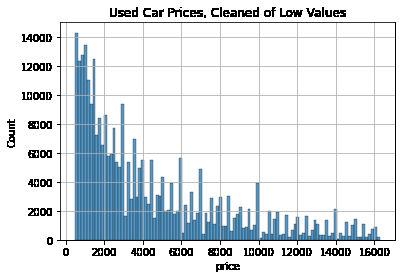

Migs Germar’s Data Science Blog - Basic Data Cleaning with eBay Car Sales Data
Гистограмма распределения цен автомобилей после очистки данных. Объясните особенности: где сосредоточены большинство объявлений, есть ли длинный хвост дорогих машин и т.д.


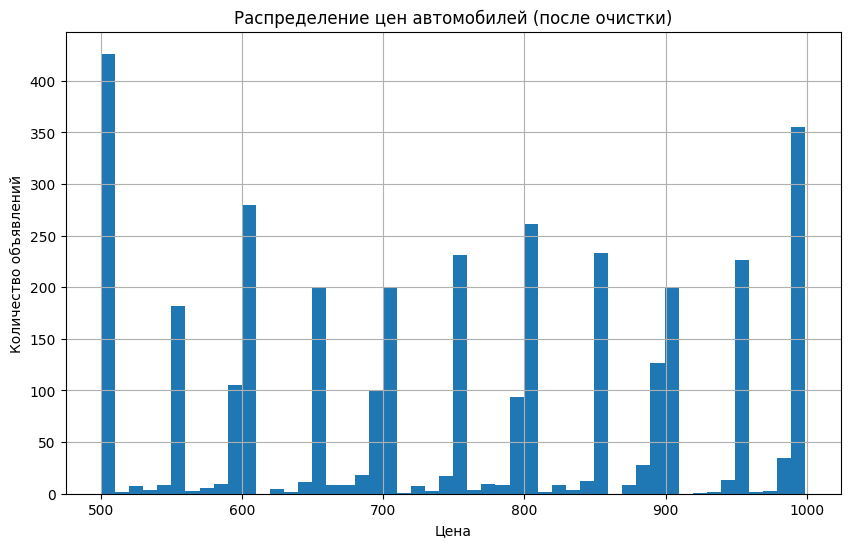

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['price'], bins=50)

plt.title('Распределение цен автомобилей (после очистки)')
plt.xlabel('Цена')
plt.ylabel('Количество объявлений')

plt.grid(True)

plt.show()

16. Взаимосвязь пробега и цены: Исследуйте связь между пробегом и ценой. Постройте диаграмму рассеяния (scatterplot) с kilometer по горизонтали и price по вертикали. Оцените корреляцию: как цена падает при увеличении пробега. Сделайте выводы и при необходимости рассчитайте коэффициент корреляции.

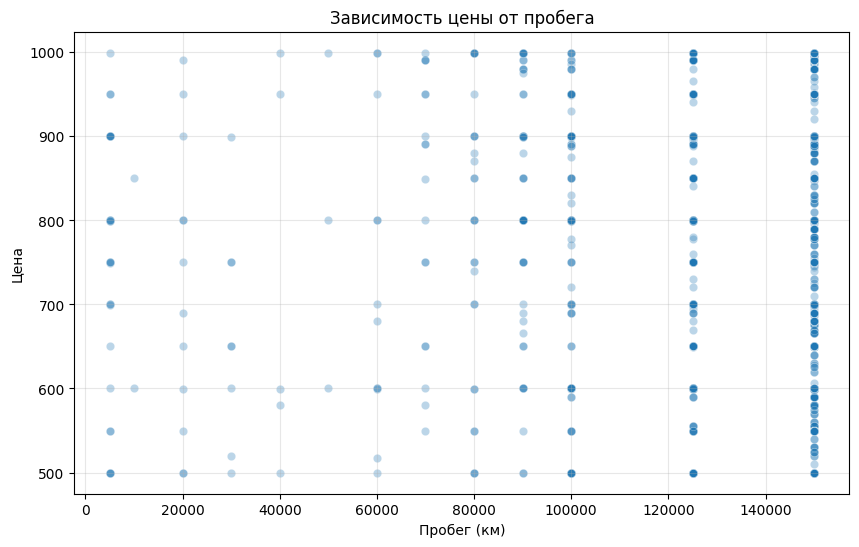

Коэффициент корреляции: -0.036


In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='odometer', y='price', alpha=0.3)

plt.title('Зависимость цены от пробега')
plt.xlabel('Пробег (км)')
plt.ylabel('Цена')

plt.grid(True, alpha=0.3)

plt.show()

corr = df['odometer'].corr(df['price'])
print(f'Коэффициент корреляции: {corr:.3f}')

17.**Анализ по маркам**:

Посмотрите, какие марки (brand) представлены в данных. Выведите число объявлений по каждой марке (df["brand"].value_counts()), а также среднюю или медианную цену для каждой марки (df.groupby("brand")["price"].median()). Отсортируйте по убыванию цены. Это покажет, какие бренды продаются дороже в среднем.

Количество объявлений по маркам:
brand
volkswagen       712
opel             577
ford             372
renault          299
bmw              186
audi             167
mercedes_benz    162
fiat             139
peugeot          132
nissan            92
seat              82
mazda             64
citroen           57
volvo             52
mitsubishi        52
alfa_romeo        39
honda             38
suzuki            28
chrysler          24
hyundai           24
kia               23
toyota            22
skoda             21
daihatsu          17
daewoo            16
saab              15
rover             15
subaru            13
smart             12
lancia            12
chevrolet          7
lada               1
dacia              1
jeep               1
jaguar             1
Name: count, dtype: int64

Медианная цена по маркам:
brand
lada             999.0
chevrolet        890.0
suzuki           820.0
skoda            800.0
seat             800.0
nissan           800.0
fiat             800.0
daewoo

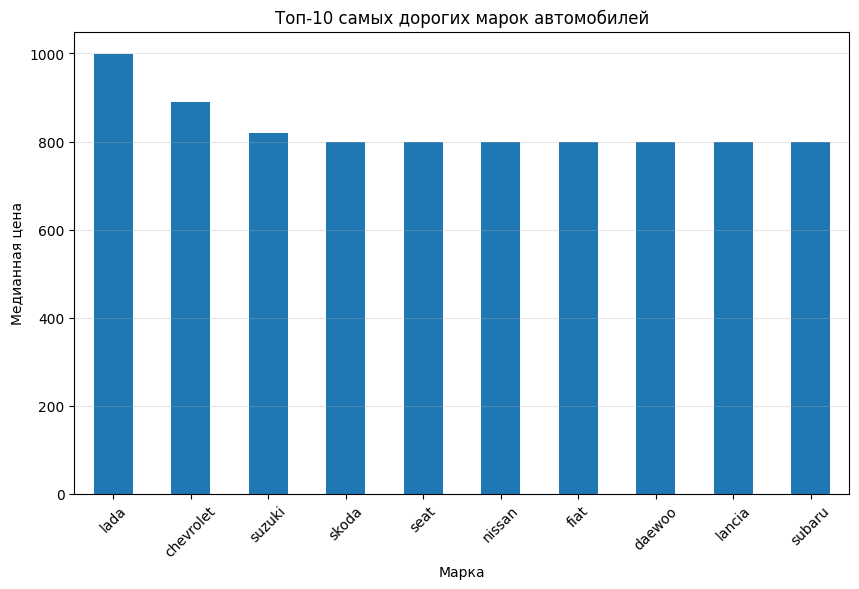

In [ ]:
brand_counts = df['brand'].value_counts()
print("Количество объявлений по маркам:")
print(brand_counts)


brand_price = df.groupby('brand')['price'].median().sort_values(ascending=False)

print("\nМедианная цена по маркам:")
print(brand_price)


top_brands = brand_price.head(10)

plt.figure(figsize=(10, 6))

top_brands.plot(kind='bar')

plt.title('Топ-10 самых дорогих марок автомобилей')
plt.xlabel('Марка')
plt.ylabel('Медианная цена')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

18.  В качестве **дальнейших шагов** можно проанализировать влияние года регистрации на цену (построить сводную таблицу или график «год регистрации – средняя цена»), сравнить цены с учётом наличия повреждений (not_repaired_damage) и т.д.

Для каждой гипотезы сформулируйте вопрос (например, «У каких марок автомобили самые дорогие?») и постройте соответствующую группировку или визуализацию.


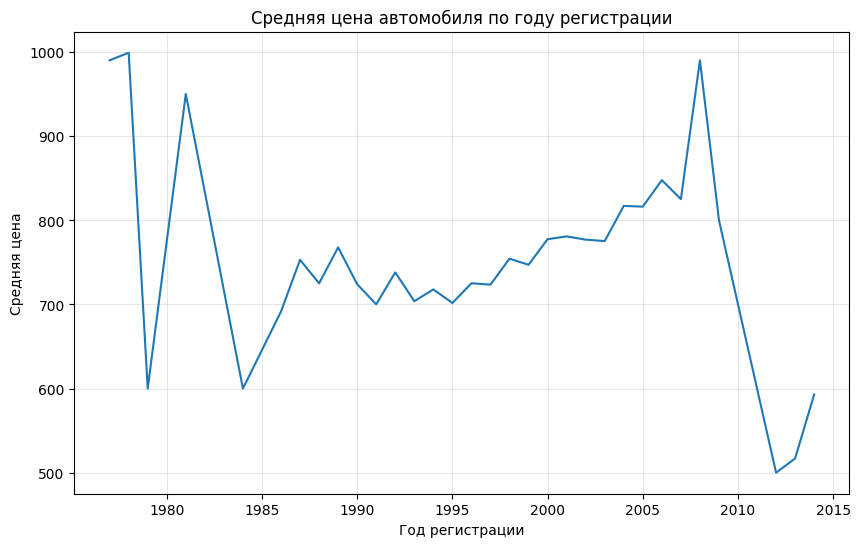

Медианная цена по состоянию (повреждения):
not_repaired_damage
ja      684.5
nein    799.0
Name: price, dtype: float64


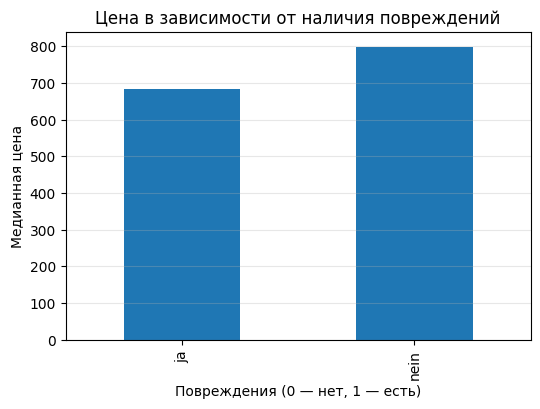

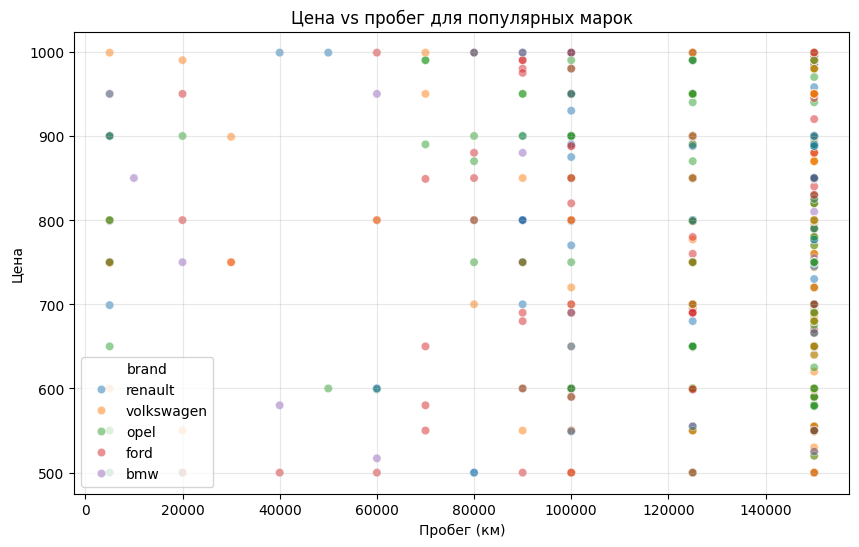

In [ ]:
year_price = df.groupby('year_of_registration')['price'].mean()

plt.figure(figsize=(10, 6))
year_price.plot()

plt.title('Средняя цена автомобиля по году регистрации')
plt.xlabel('Год регистрации')
plt.ylabel('Средняя цена')

plt.grid(True, alpha=0.3)
plt.show()

damage_price = df.groupby('not_repaired_damage')['price'].median()

print("Медианная цена по состоянию (повреждения):")
print(damage_price)

plt.figure(figsize=(6, 4))
damage_price.plot(kind='bar')

plt.title('Цена в зависимости от наличия повреждений')
plt.xlabel('Повреждения (0 — нет, 1 — есть)')
plt.ylabel('Медианная цена')

plt.grid(axis='y', alpha=0.3)
plt.show()

top_brands = df['brand'].value_counts().head(5).index
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_top,
    x='odometer',
    y='price',
    hue='brand',
    alpha=0.5
)

plt.title('Цена vs пробег для популярных марок')
plt.xlabel('Пробег (км)')
plt.ylabel('Цена')

plt.grid(True, alpha=0.3)
plt.show()


**Резюме**: После выполнения заданий вы получите очищенный и проанализированный датасет. Вы узнаете основные характеристики объявлений (средние цены, распространённый пробег), а также увидите, как различается цена по маркам и годам. Эти выводы будут подтверждены с помощью статистик и графиков (например, гистограммы цен) – цель достижения полного понимания структуры данных.